# Modulated Delay Effects

Both effects mix the original signal with a copy read from a continuously modulated delay tap. The LFO rate and delay range determine the character:

- **Chorus** uses a longer centre delay (20–30 ms) so the modulated copy is clearly detuned; multiple voices are summed to create a thick, spacious texture.
- **Flanger** uses a very short delay (0.5–5 ms) so the comb-filter notches fall in the audio band; feedback makes the notches sharper and creates the characteristic metallic sweep.

| Function | Description |
| --- | --- |
| `chorus` | Mix signal with a sinusoidally modulated delayed copy (20–30 ms centre delay). LFO depth and rate control the detuning width and speed. |
| `flanger` | Short modulated delay (0.5–5 ms) with IIR feedback, producing sweeping comb-filter notches. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.delay import chorus, flanger
from python.generators import generate_impulse, generate_sine

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Static-delay frequency responses and time-domain waveforms for a 440 Hz sine.

**2 × 2 grid:**
- **Top-left — chorus waveform:** dry and processed signals overlaid over 50 ms; the modulated delay causes slight pitch deviation and waveform spreading relative to dry
- **Top-right — flanger waveform:** more dramatic amplitude variation from the short delay; beating between dry and the comb-filter copy
- **Bottom-left — chorus frequency response:** gentle, smooth ripple pattern; comb peaks spaced at ~1/(centre_delay) Hz intervals; depth of dips grows with mix level
- **Bottom-right — flanger frequency response:** sharp harmonic comb pattern at multiples of fs/D; feedback amplifies every resonant peak, narrowing the dips

The LFO sweeps the delay continuously in practice; the static-delay frequency response shows the *instantaneous* comb pattern at one snapshot in time.


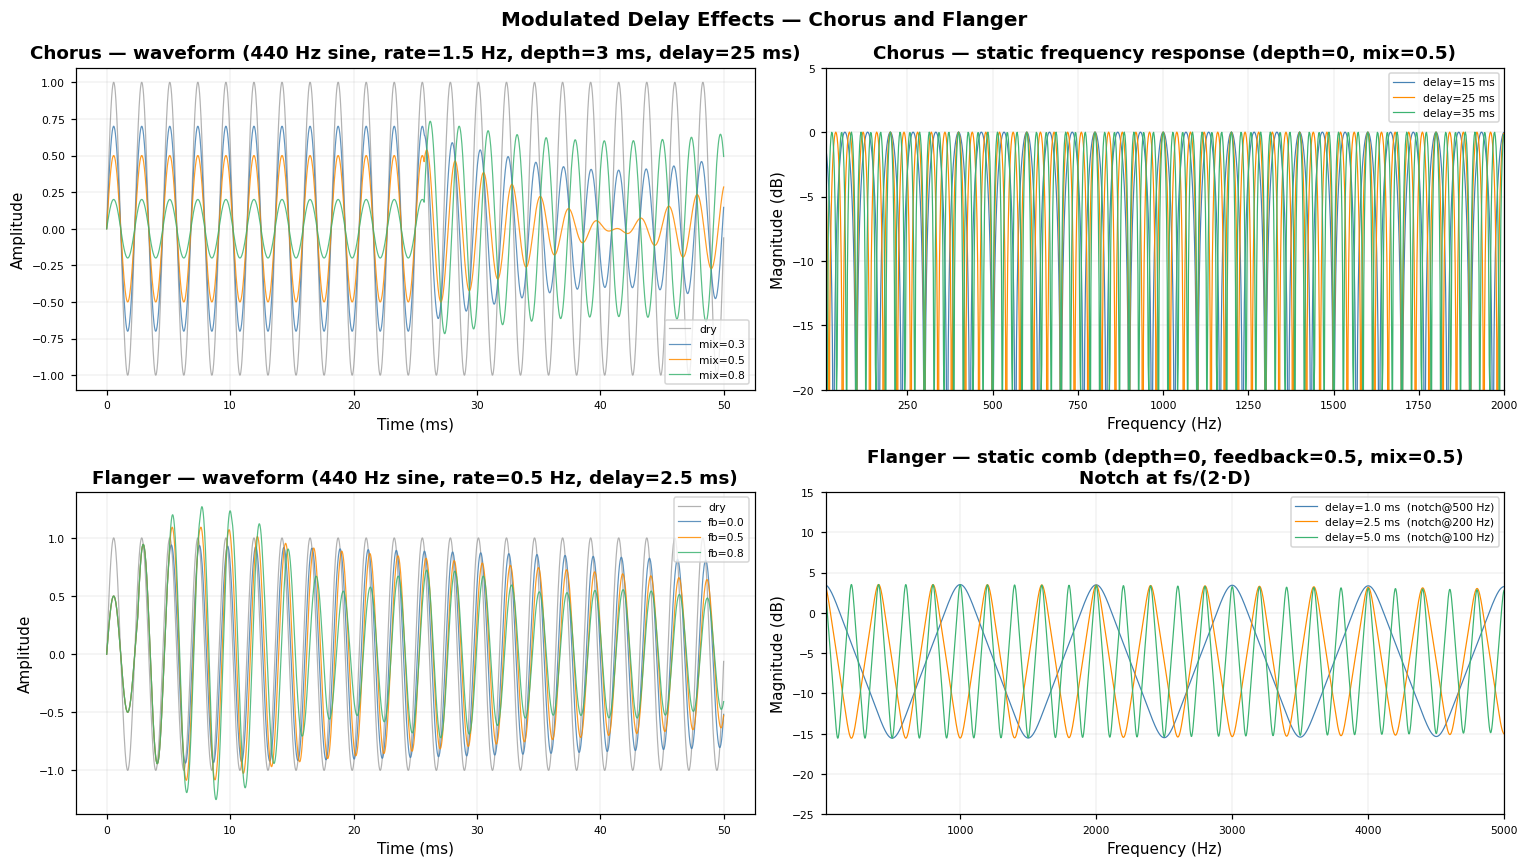

In [2]:
DURATION = 0.5

_, impulse = generate_impulse(fs=FS, duration=DURATION)
_, sine = generate_sine(freq=440.0, fs=FS, duration=0.05)
t_ms = np.arange(len(sine)) / FS * 1000


def _freq_response(h):
    spectrum = np.abs(np.fft.rfft(h))
    freqs = np.fft.rfftfreq(len(h), d=1.0 / FS)
    db = 20.0 * np.log10(spectrum + 1e-12)
    return freqs, db


COLORS = ["steelblue", "darkorange", "mediumseagreen", "crimson"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# chorus waveform
ax = axes[0, 0]
ax.plot(t_ms, sine, color="gray", linewidth=0.8, label="dry", alpha=0.6)
for mix, color in zip([0.3, 0.5, 0.8], COLORS):
    ch = chorus(sine, rate=1.5, depth_ms=3.0, delay_ms=25.0, mix=mix, fs=FS)
    ax.plot(t_ms, ch, linewidth=0.8, color=color, label=f"mix={mix}", alpha=0.85)
ax.set_title("Chorus — waveform (440 Hz sine, rate=1.5 Hz, depth=3 ms, delay=25 ms)",
             fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.3, alpha=0.5)

# chorus frequency response
ax = axes[0, 1]
for d_ms, color in zip([15.0, 25.0, 35.0], COLORS):
    h = chorus(impulse, rate=0.0, depth_ms=0.0, delay_ms=d_ms, mix=0.5, fs=FS)
    freqs, db = _freq_response(h)
    mask = (freqs > 10) & (freqs < 2000)
    ax.plot(freqs[mask], db[mask], linewidth=0.8, color=color, label=f"delay={d_ms:.0f} ms")
ax.set_title("Chorus — static frequency response (depth=0, mix=0.5)", fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(10, 2000)
ax.set_ylim(-20, 5)
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.3, alpha=0.5)

# flanger waveform
ax = axes[1, 0]
ax.plot(t_ms, sine, color="gray", linewidth=0.8, label="dry", alpha=0.6)
for fb, color in zip([0.0, 0.5, 0.8], COLORS):
    fl = flanger(sine, rate=0.5, depth_ms=1.5, delay_ms=2.5, feedback=fb, mix=0.5, fs=FS)
    ax.plot(t_ms, fl, linewidth=0.8, color=color, label=f"fb={fb}", alpha=0.85)
ax.set_title("Flanger — waveform (440 Hz sine, rate=0.5 Hz, delay=2.5 ms)",
             fontweight="bold")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.3, alpha=0.5)

# flanger static comb
ax = axes[1, 1]
for d_ms, color in zip([1.0, 2.5, 5.0], COLORS):
    h = flanger(impulse, rate=0.0, depth_ms=0.0, delay_ms=d_ms, feedback=0.5, mix=0.5, fs=FS)
    freqs, db = _freq_response(h)
    d_s = d_ms * FS / 1000.0
    first_notch = FS / (2 * d_s)
    mask = (freqs > 10) & (freqs < 5000)
    ax.plot(freqs[mask], db[mask], linewidth=0.8, color=color,
            label=f"delay={d_ms} ms  (notch@{first_notch:.0f} Hz)")
ax.set_title("Flanger — static comb (depth=0, feedback=0.5, mix=0.5)\nNotch at fs/(2·D)",
             fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(10, 5000)
ax.set_ylim(-25, 15)
ax.legend(fontsize=7)
ax.grid(True, linewidth=0.3, alpha=0.5)

for ax in axes.flat:
    ax.tick_params(labelsize=7)

fig.suptitle("Modulated Delay Effects — Chorus and Flanger", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Chorus and flanger are both modulated delays — the difference is the delay range. Flanger uses very short delays (1–5 ms) so the comb notches sweep through the audible range; chorus uses longer delays (20–30 ms) for a doubling/widening effect.


In [3]:
from IPython.display import Audio, display

DUR_A = 3.0
t_a   = np.arange(int(FS * DUR_A)) / FS
saw_a = 0.5 * (2 * ((110.0 * t_a) % 1.0) - 1.0)

ch_a = chorus(saw_a, rate=1.0, depth_ms=2.5, delay_ms=25.0, mix=0.5, fs=FS)
fl_a = flanger(saw_a, rate=0.5, depth_ms=2.0, delay_ms=2.5, feedback=0.7, mix=0.5, fs=FS)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Dry sawtooth at 110 Hz")
display(Audio(saw_a, rate=FS))
print("Chorus (rate=1 Hz, depth=2.5 ms, delay=25 ms) — warm doubling effect")
display(Audio(norm(ch_a), rate=FS))
print("Flanger (rate=0.5 Hz, depth=2 ms, delay=2.5 ms, feedback=0.7) — sweeping jet sound")
display(Audio(norm(fl_a), rate=FS))

Dry sawtooth at 110 Hz


Chorus (rate=1 Hz, depth=2.5 ms, delay=25 ms) — warm doubling effect


Flanger (rate=0.5 Hz, depth=2 ms, delay=2.5 ms, feedback=0.7) — sweeping jet sound
